# COMP 352 Final Project

**Authors: Elbron Jackob, Cory Tamburrino, Anthony Frago, Benjamin Cavallari**

**Date: 04/29/2026**

### Student Dropout

### Full Dataset: https://www.kaggle.com/datasets/mohamedasak/online-learning-student-dropout-dataset

This dataset simulates behavioral and demographic data for 5,000 students enrolled in online learning platforms. 

It is designed for building and evaluating machine learning models that predict student dropout risk.



## Final Project Requirements

- **Data Importing and Pre-processing (100 Points)**
    - Import dataset and describe characteristics such as dimensions, data types, file types, and import methods used
    - Clean, wrangle, and handle missing data, duplicate data, etc.
    - Encode any categorical variables
    - Perform feature engineering on the dataset
    - Transform data appropriately using techniques such as aggregation, normalization, and feature construction
    - Reduce redundant data and perform need based discretization
- **Data Analysis and Visualization (100 Points)**
    - Identify categorical, ordinal, and numerical variables within data
    - Provide measures of centrality and distribution with visualizations
    - Diagnose for correlations between variables and determine independent and dependent variables
    - Perform exploratory analysis in combination with visualization techniques to discover patterns and features of interest
    - Create visualizations that allow for the discovery of insights in the data
- **Data Analytics (100 Points)**
    - Determine the need for a supervised or unsupervised learning method and identify dependent and independent variables
    - Choose and provide reasoning for the selected metric or metrics employed to assess your model.
    - Train, test, cross validate, and provide performance metrics for model results
    - Try multiple different types of algorithms to determine the best model for your dataset
    - Analyze your model performance
- **Presentation & Peer Evaluation (50 Points)**
    - In a 15 to 30 slide presentation, briefly explain the project workflow from the code and results from your Jupyter notebook. You must include information that is not found on each slides in the "Notes" section of your presentation. (See presentation example  for an outline of what the presentation should look like)
    - This presentation must be submitted by the university-scheduled final exam time for the course. It will not be presented in person; only the final project materials need to be submitted
    - State your findings from the data and provide the interpretation of results from your analysis at each stage in the project
    - Be sure to properly label visualizations in your presentation (axis labels, human readable column names, etc.) 
    - Complete the peer evaluation form  for each member of the group

Note: Matplotlib & scipy is not supported on python 3.15

## Table of Contents:
* [Environment Setup](#env-setup)
* [Data Importing and Pre-processing](#data-importing)
* [Data Analysis and Visualization](#data-vis)
* [Data Analytics](#data-analytics)

## Environment Setup <a class="anchor" id="env-setup"></a>

First we must setup our environment. To do this, use the ```requirements.txt``` file to download the modules via ```pip```.

You may need to install setup tools. To do this run (Note you may need to change ```pip3``` to ```pip```):
```bash
pip3 install --upgrade pip setuptools wheel
```

and then run:
```bash
pip3 install -r env_setup/requirements.txt
```
```bash
conda env create -f env_setup/data_environment.yml
```
Then activate the environment by:
```bash
conda activate data_env
```

## Data Importing and Pre-processing <a class="anchor" id="data-importing"></a>


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

student_df = pd.read_csv("data/student_dropout_dataset.csv")

## 1. Records and columns

In [3]:
n_rows, n_cols = student_df.shape
print(f"Number of records (rows): {n_rows:,}")
print(f"Number of columns (fields): {n_cols}")

Number of records (rows): 5,000
Number of columns (fields): 15


## 2. Column data types — numeric vs categorical

Pandas `object` columns are treated as categorical/text for counting. `student_id` is an identifier (not a modeling feature). `enroll_date` is stored as strings and can be parsed to datetime if you use it as a feature.


In [4]:
num_mask = student_df.select_dtypes(include=[np.number]).columns
obj_mask = student_df.select_dtypes(include=["object", "category", "bool"]).columns

print("Numeric columns:", len(num_mask))
print(list(num_mask))
print()
print("Categorical columns:", len(obj_mask))
print(list(obj_mask))

feature_like_numeric = [c for c in num_mask if c not in {"label", "label_multiclass"}]
print()
print("Numeric columns excluding obvious targets (label, label_multiclass):", len(feature_like_numeric))
print(feature_like_numeric)

Numeric columns: 11
['age', 'exam_season', 'courses_enrolled', 'completed_assignments', 'completion_rate', 'login_frequency', 'last_activity_days_ago', 'forum_posts_count', 'dropout_score', 'label', 'label_multiclass']

Categorical columns: 4
['student_id', 'region', 'enroll_date', 'label_name']

Numeric columns excluding obvious targets (label, label_multiclass): 9
['age', 'exam_season', 'courses_enrolled', 'completed_assignments', 'completion_rate', 'login_frequency', 'last_activity_days_ago', 'forum_posts_count', 'dropout_score']


In [5]:
student_df.head()

,student_id,age,region,enroll_date,exam_season,courses_enrolled,completed_assignments,completion_rate,login_frequency,last_activity_days_ago,forum_posts_count,dropout_score,label,label_multiclass,label_name
0,STU00001,26,Alexandria,2024-01-13,0,3,5,0.3571,5.29,10,5,0.1064,0,0,active
1,STU00002,23,Amman,2024-05-05,0,6,0,0.0000,0.84,7,0,0.6627,1,2,dropped
2,STU00003,17,Dubai,2024-03-12,0,3,1,0.0435,1.79,36,0,0.7299,1,2,dropped
3,STU00004,23,Alexandria,2024-12-12,0,6,13,0.4396,0.78,9,0,0.5315,1,1,at-risk
4,STU00005,20,Baghdad,2024-02-14,0,5,5,0.2078,0.92,11,0,0.7904,1,2,dropped


## Drop unwanted columns

Dropping other potential target columns: dropout_score, label_multiclass, label_name

In [6]:
student_df = student_df.drop(columns=["dropout_score", "label_multiclass", "label_name"])

In [7]:
student_df.head()

,student_id,age,region,enroll_date,exam_season,courses_enrolled,completed_assignments,completion_rate,login_frequency,last_activity_days_ago,forum_posts_count,label
0,STU00001,26,Alexandria,2024-01-13,0,3,5,0.3571,5.29,10,5,0
1,STU00002,23,Amman,2024-05-05,0,6,0,0.0000,0.84,7,0,1
2,STU00003,17,Dubai,2024-03-12,0,3,1,0.0435,1.79,36,0,1
3,STU00004,23,Alexandria,2024-12-12,0,6,13,0.4396,0.78,9,0,1
4,STU00005,20,Baghdad,2024-02-14,0,5,5,0.2078,0.92,11,0,1


## 3. NULL % per column

In [8]:
null_pct = (student_df.isna().mean() * 100).round(4)
display(null_pct.to_frame("null_pct"))
print("Any missing values?", student_df.isna().any().any())

,null_pct
student_id,0.0
age,0.0
region,0.0
enroll_date,0.0
exam_season,0.0
courses_enrolled,0.0
completed_assignments,0.0
completion_rate,0.0
login_frequency,0.0
last_activity_days_ago,0.0


Any missing values? False


## 4. Class balance check

Binary label (label) balance:
label
0    1704
1    3296
Name: count, dtype: int64

Class percentages (%):
label
0    34.08
1    65.92
Name: count, dtype: float64


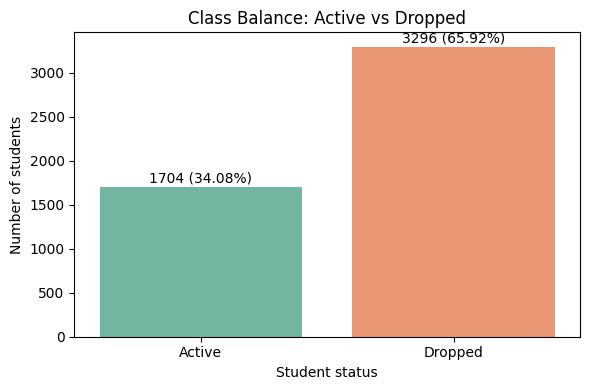

In [9]:
# Class counts and percentages (binary target)
class_counts = student_df["label"].value_counts().sort_index()
class_pct = (class_counts / class_counts.sum() * 100).round(2)

print("Binary label (label) balance:")
print(class_counts)
print("\nClass percentages (%):")
print(class_pct)

plot_counts = class_counts.rename(index={0: "Active", 1: "Dropped"}).reset_index()
plot_counts.columns = ["status", "count"]

plt.figure(figsize=(6, 4))
ax = sns.barplot(data=plot_counts, x="status", y="count", hue="status", palette="Set2", legend=False)
for i, row in plot_counts.iterrows():
    pct = class_pct.loc[0] if row["status"] == "Active" else class_pct.loc[1]
    ax.text(i, row["count"] + 20, f"{row['count']} ({pct}%)", ha="center", va="bottom", fontsize=10)
plt.title("Class Balance: Active vs Dropped")
plt.xlabel("Student status")
plt.ylabel("Number of students")
plt.tight_layout()
plt.show()


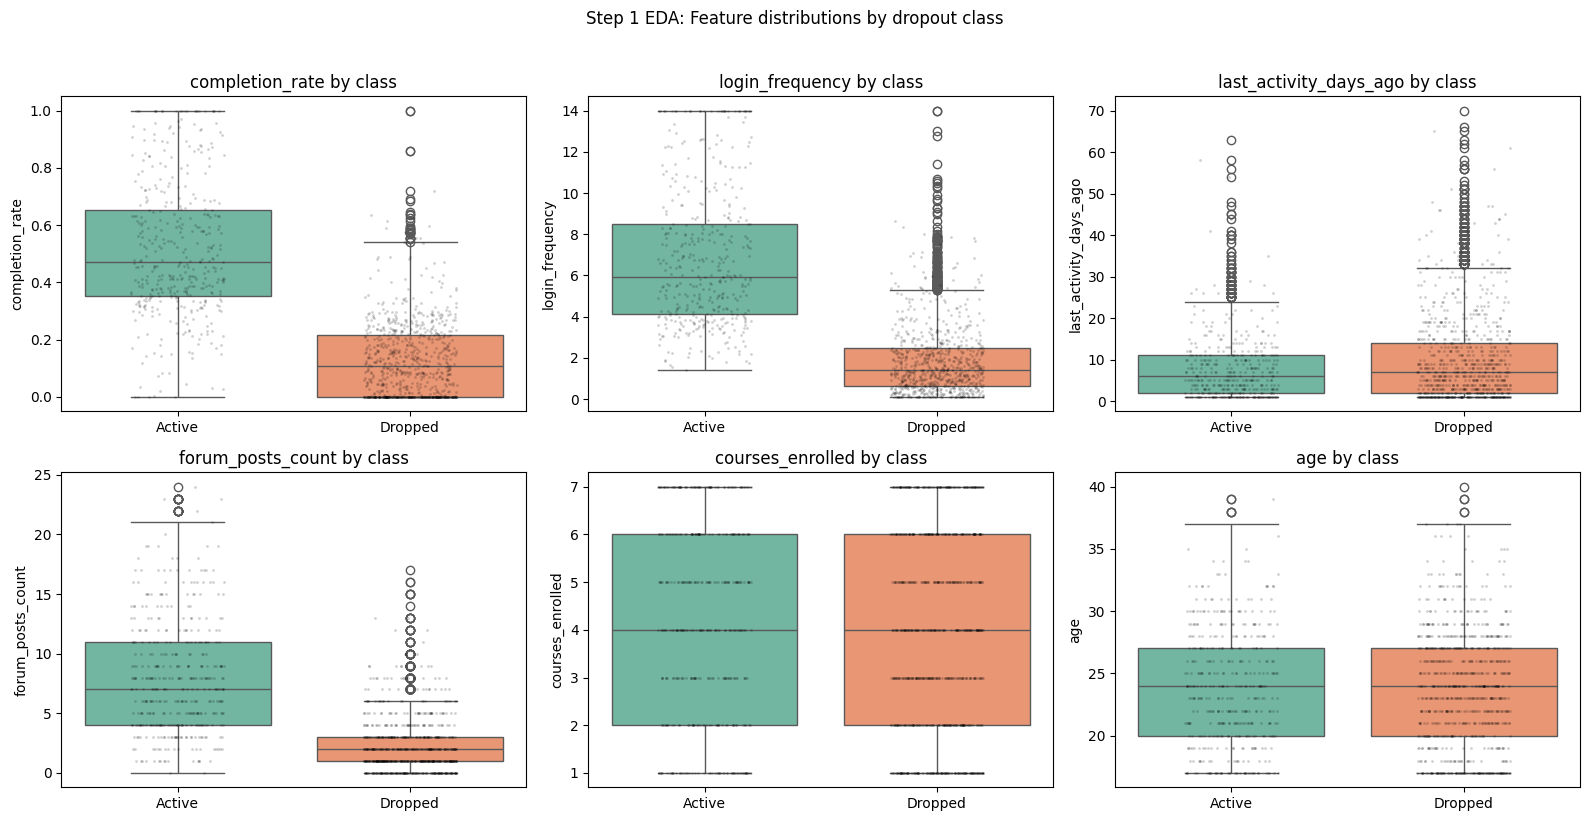

In [ ]:
# Feature-by-class visuals (classification-friendly alternative to target scatter)
plot_df = student_df.copy()
plot_df["status"] = plot_df["label"].map({0: "Active", 1: "Dropped"})

features_to_plot = [
    "completion_rate",
    "login_frequency",
    "last_activity_days_ago",
    "forum_posts_count",
    "courses_enrolled",
    "age",
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.ravel()

for ax, feature in zip(axes, features_to_plot):
    sns.boxplot(data=plot_df, x="status", y=feature, ax=ax, hue="status", palette="Set2", legend=False)
    sns.stripplot(
        data=plot_df.sample(min(1200, len(plot_df)), random_state=42),
        x="status",
        y=feature,
        ax=ax,
        color="black",
        alpha=0.18,
        size=2,
        jitter=0.2,
    )
    ax.set_title(f"{feature} by class")
    ax.set_xlabel("")

plt.suptitle("EDA: Feature distributions by dropout class", y=1.02)
plt.tight_layout()
plt.show()


### 5. Check for Duplicate student id's

Check for duplicate `student_id` values.


In [11]:
dup_id = student_df["student_id"].duplicated().sum()
nunique_id = student_df["student_id"].nunique()
print(f"Duplicate student_id: {dup_id}")
print(f"Unique student_id: {nunique_id}  (rows: {len(student_df)})")


Duplicate student_id: 0
Unique student_id: 5000  (rows: 5000)


### 6. Check for outliers

Extreme values were retained because they represent meaningful student behavior associated with dropout risk rather than data-entry errors.”

### 7. Feature engineering: enrollment date

Parse `enroll_date` and extract **`enroll_month`** (1–12) as a simple calendar feature. **`enroll_date` itself is not included in `X`**—only **`enroll_month`**—so the model does not receive the raw date column as a feature (the datetime remains on `student_df` for reference).  All entries in the dataset have the same year, and the individual days are noisy, so the month will be the only date representation that is fed into the model.

In [12]:
student_df["enroll_date"] = pd.to_datetime(student_df["enroll_date"])
student_df["enroll_month"] = student_df["enroll_date"].dt.month.astype(int)
student_df[["enroll_date", "enroll_month"]].head()

,enroll_date,enroll_month
0,2024-01-13,1
1,2024-05-05,5
2,2024-03-12,3
3,2024-12-12,12
4,2024-02-14,2


### 8. Reducing redundancy

`completion_rate` is almost perfectly determined by `completed_assignments` / `courses_enrolled`, so keeping all three creates **strong multicollinearity** for linear models. We **keep `completion_rate` and `courses_enrolled`** (workload and normalized progress) and **drop `completed_assignments`**, which is the most redundant of the two count-based pieces given the rate is already in the data.


In [13]:
student_df = student_df.drop(columns=["completed_assignments"])
student_df.head()

,student_id,age,region,enroll_date,exam_season,courses_enrolled,completion_rate,login_frequency,last_activity_days_ago,forum_posts_count,label,enroll_month
0,STU00001,26,Alexandria,2024-01-13,0,3,0.3571,5.29,10,5,0,1
1,STU00002,23,Amman,2024-05-05,0,6,0.0000,0.84,7,0,1,5
2,STU00003,17,Dubai,2024-03-12,0,3,0.0435,1.79,36,0,1,3
3,STU00004,23,Alexandria,2024-12-12,0,6,0.4396,0.78,9,0,1,12
4,STU00005,20,Baghdad,2024-02-14,0,5,0.2078,0.92,11,0,1,2


### 9. Modeling matrix: features, encoding, `X` and `y`

- **`student_id`**: excluded from features (identifier).
- **`region`**: **one-hot** encoding with `drop_first=True` to avoid the dummy-variable trap in linear models.
- **Numeric features**: `age`, `exam_season`, `courses_enrolled`, `completion_rate`, engagement columns, `enroll_month`.
- **Target**: `label`.


In [14]:
numeric_features = [
    "age",
    "exam_season",
    "courses_enrolled",
    "completion_rate",
    "login_frequency",
    "last_activity_days_ago",
    "forum_posts_count",
    "enroll_month",
]

X_num = student_df[numeric_features].copy()
region_dummies = pd.get_dummies(student_df["region"], prefix="region", drop_first=True)
X = pd.concat([X_num, region_dummies], axis=1)
y = student_df["label"].copy()
feature_cols = list(X.columns)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of features:", len(feature_cols))
X.head()


X shape: (5000, 17)
y shape: (5000,)
Number of features: 17


,age,exam_season,courses_enrolled,completion_rate,login_frequency,last_activity_days_ago,forum_posts_count,enroll_month,region_Amman,region_Baghdad,region_Beirut,region_Cairo,region_Casablanca,region_Doha,region_Dubai,region_Riyadh,region_Tunis
0,26,0,3,0.3571,5.29,10,5,1,False,False,False,False,False,False,False,False,False
1,23,0,6,0.0000,0.84,7,0,5,True,False,False,False,False,False,False,False,False
2,17,0,3,0.0435,1.79,36,0,3,False,False,False,False,False,False,True,False,False
3,23,0,6,0.4396,0.78,9,0,12,False,False,False,False,False,False,False,False,False
4,20,0,5,0.2078,0.92,11,0,2,False,True,False,False,False,False,False,False,False


### 10. Double bar charts by feature vs dropout status

For each feature, this section plots side-by-side bars showing the number of students in each feature value (or value bucket) split by status (`Active` vs `Dropped`).

- **Y-axis:** number of students
- **X-axis:** feature value / bucket
- **Two bars per X value:** one for `Active`, one for `Dropped`

For numeric features with many unique values, values are grouped into quantile buckets to make outlier spikes easier to see.

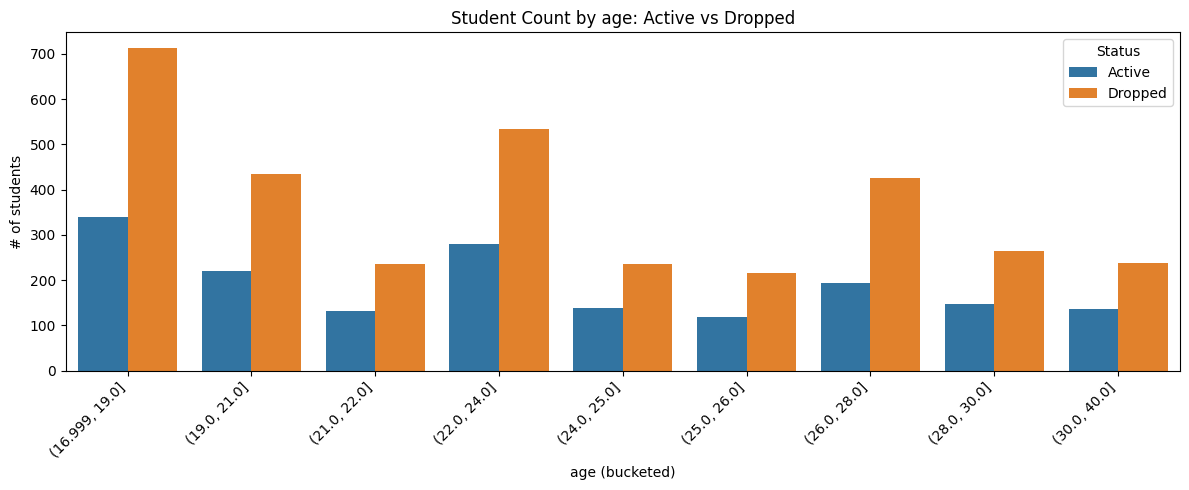

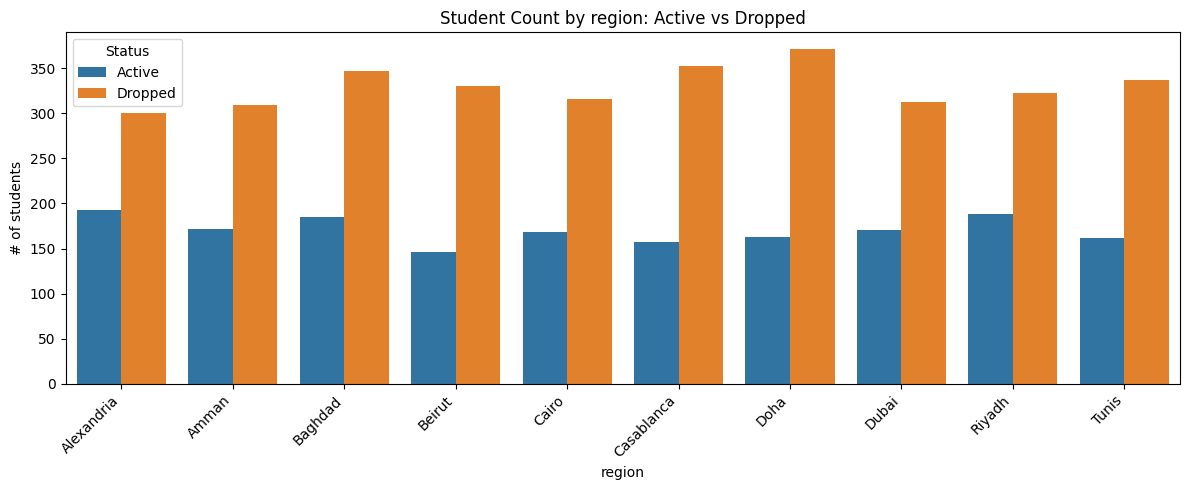

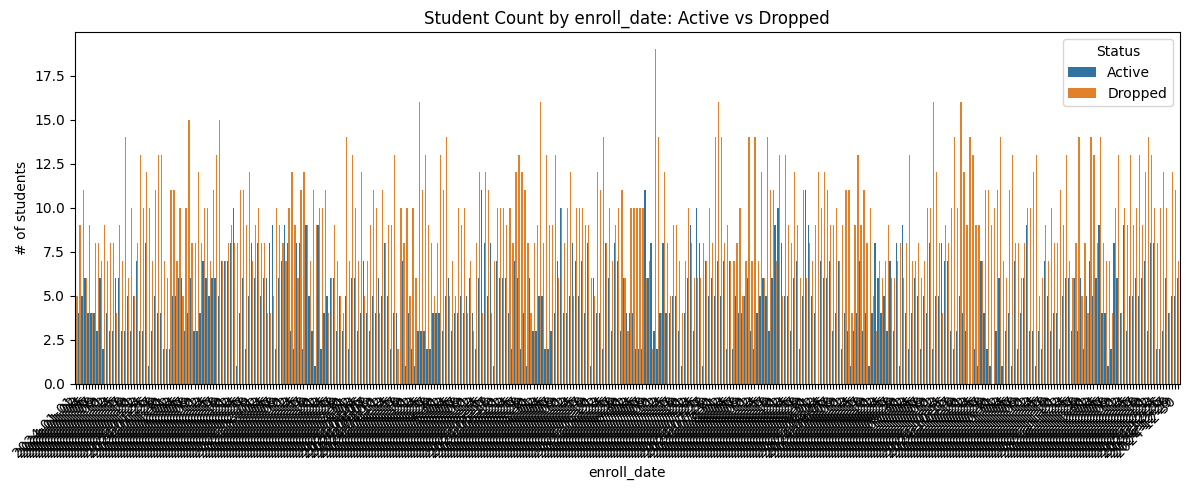

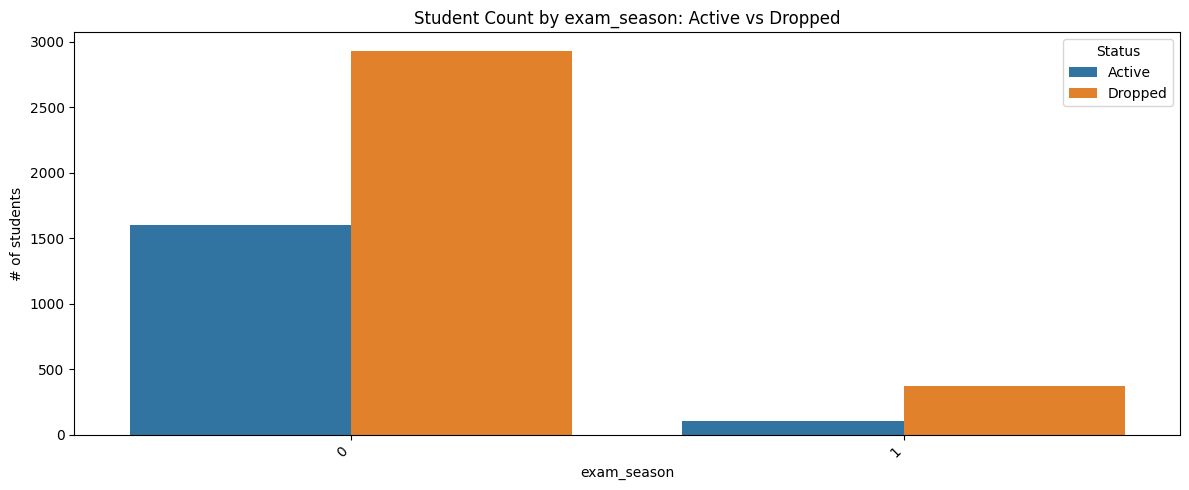

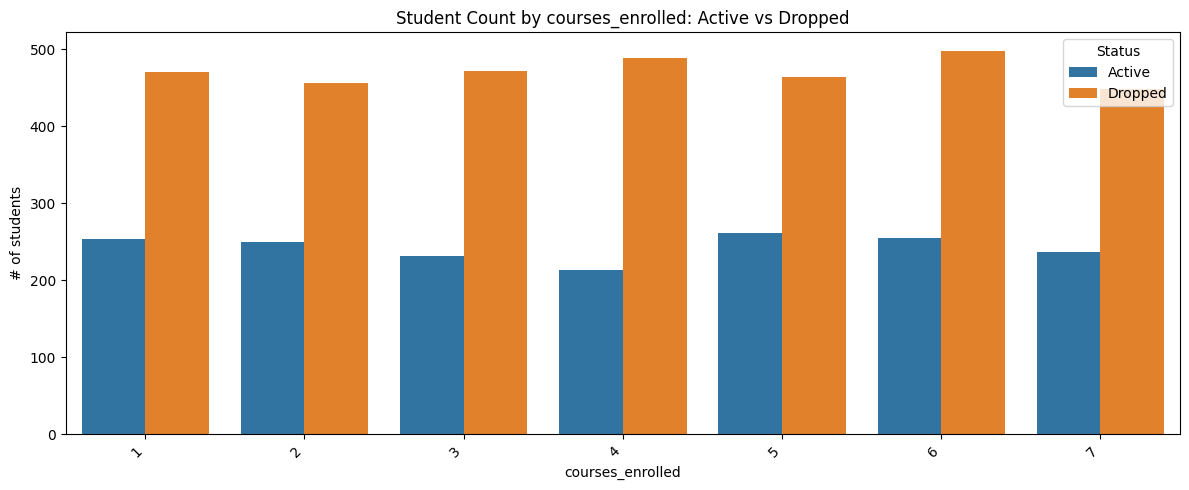

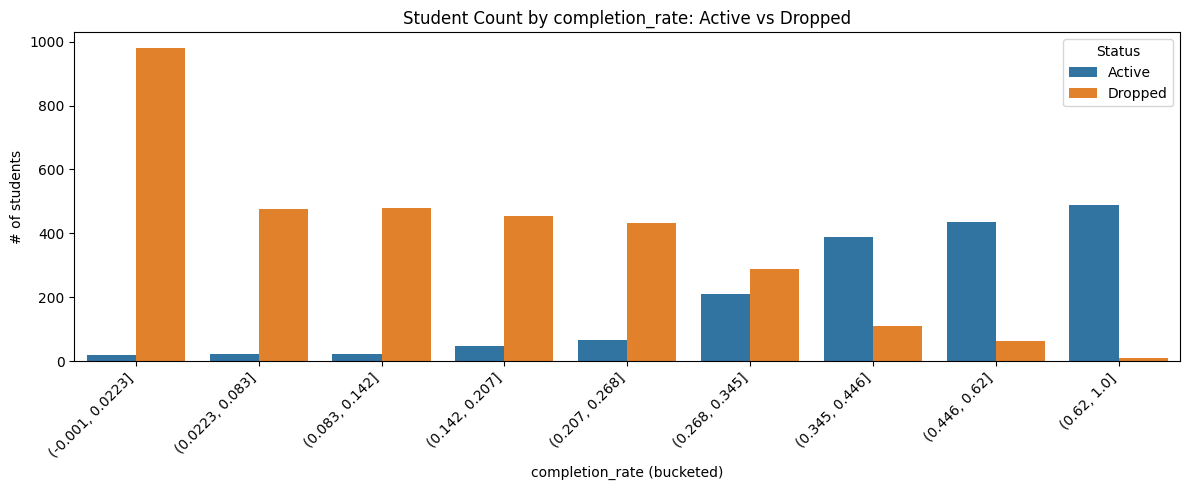

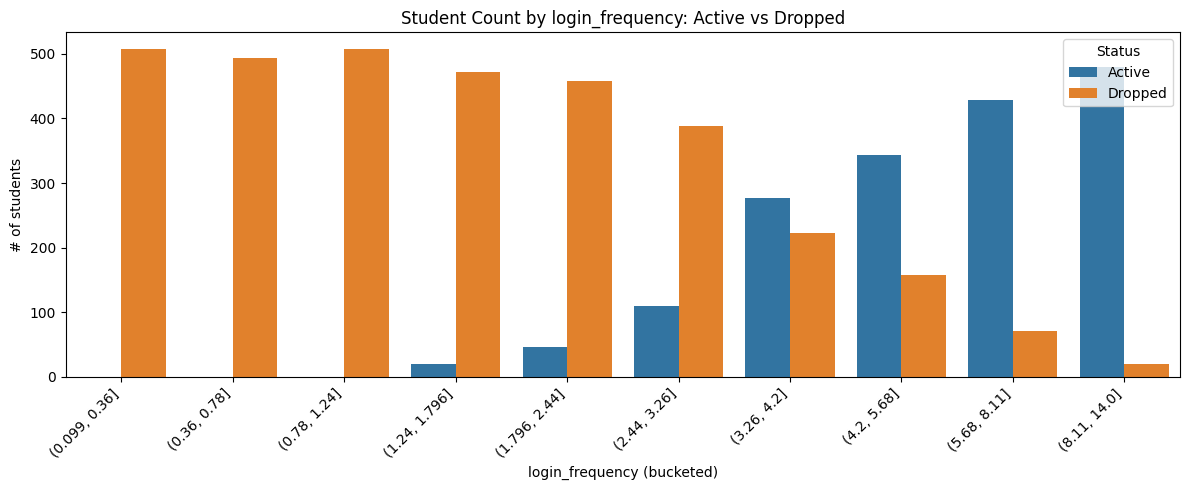

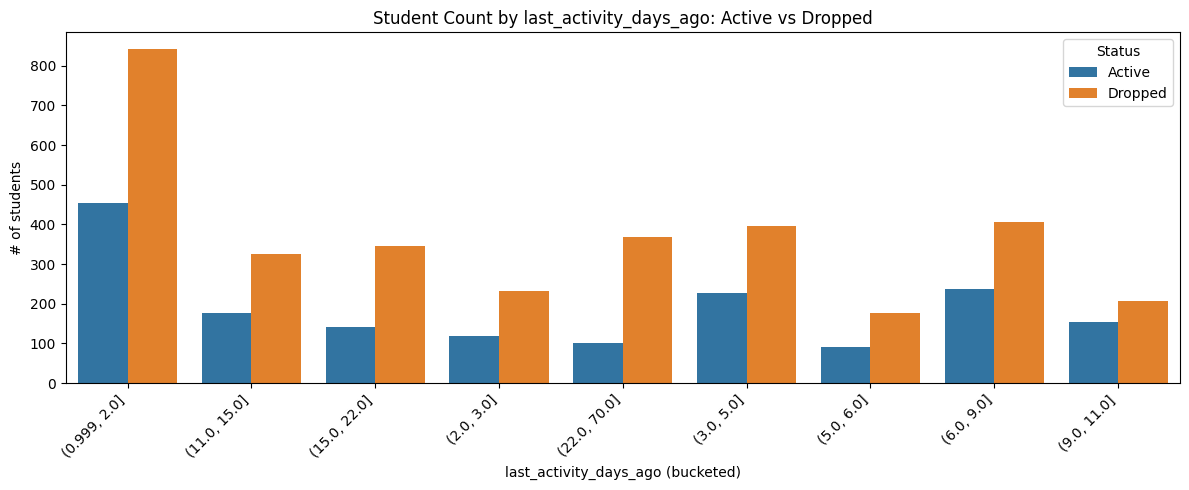

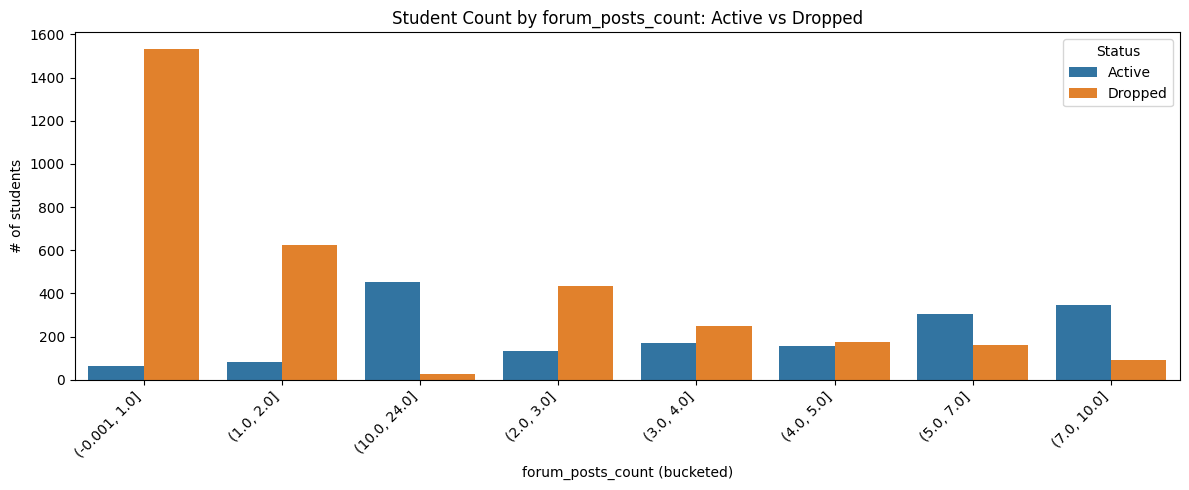

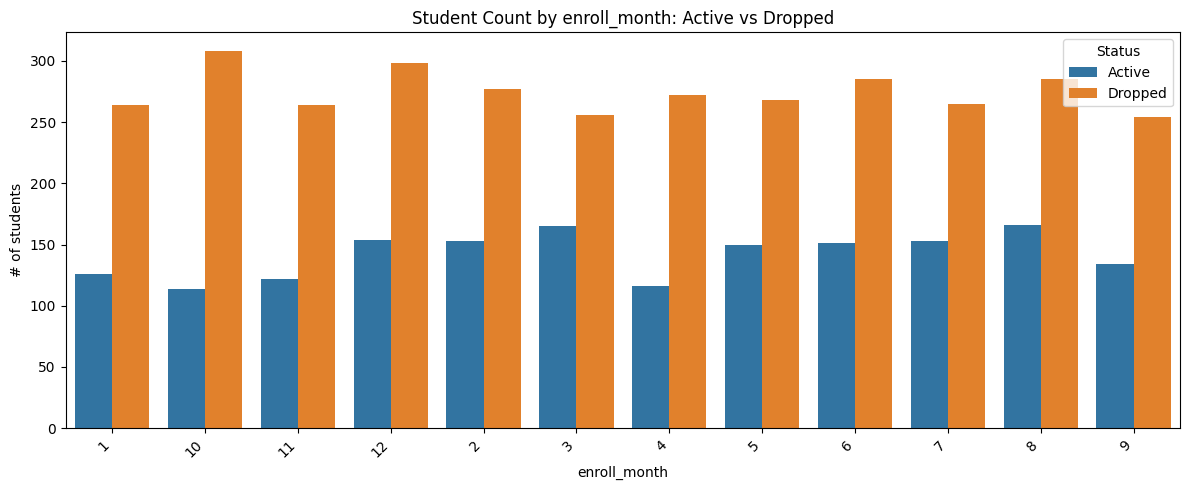

In [15]:
# Build label names for plotting
plot_df = student_df.copy()
plot_df["status"] = plot_df["label"].map({0: "Active", 1: "Dropped"}).fillna(plot_df["label"].astype(str))

# Exclude identifiers/targets from feature list
exclude_cols = {"student_id", "label"}
feature_vars = [c for c in plot_df.columns if c not in exclude_cols and c != "status"]

# Settings
max_unique_without_binning = 20
num_quantile_bins = 10

for col in feature_vars:
    temp = plot_df[[col, "status"]].dropna().copy()

    # Bucket high-cardinality numeric features to keep charts readable.
    if pd.api.types.is_numeric_dtype(temp[col]) and temp[col].nunique() > max_unique_without_binning:
        try:
            temp["x_value"] = pd.qcut(temp[col], q=num_quantile_bins, duplicates="drop")
        except ValueError:
            temp["x_value"] = pd.cut(temp[col], bins=num_quantile_bins)
        x_label = f"{col} (bucketed)"
    else:
        temp["x_value"] = temp[col]
        x_label = col

    # Count students for each x value split by status (Active vs Dropped)
    counts = (
        temp.groupby(["x_value", "status"], observed=False)
        .size()
        .reset_index(name="student_count")
    )

    # Keep axis ordering stable/readable
    x_order = sorted(counts["x_value"].unique(), key=lambda x: str(x))

    plt.figure(figsize=(12, 5))
    sns.barplot(
        data=counts,
        x="x_value",
        y="student_count",
        hue="status",
        order=x_order,
        hue_order=["Active", "Dropped"],
    )
    plt.title(f"Student Count by {col}: Active vs Dropped")
    plt.xlabel(x_label)
    plt.ylabel("# of students")
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Status")
    plt.tight_layout()
    plt.show()